# Section 3: Partial Equilibrium European Gas Market Model
**Member 1** — Work on this section, then integrate into the main notebook.

**Your responsibility:** Supply/demand functions, calibration, shock simulation, equilibrium solving (secant + scipy), Norwegian producer surplus (analytical + numerical). You should be able to explain: constant-elasticity forms, the secant method, how the supply shock is modeled, and how producer surplus is computed via integration.

---

*The setup cells below (imports + solvers) are shared across all members.*

# Who Gains When Gas Prices Surge?
## A Welfare Analysis of Norway's Gas Economy Under the Ukraine War Supply Shock

**EBA3650 — Quantitative Economics**
BI Norwegian Business School | Spring 2026 | Group of 4

### Research Question

The 2022 Russian invasion of Ukraine triggered one of the largest energy supply shocks in recent history. As Russian pipeline gas to Europe was curtailed — from roughly 155 bcm/year to under 30 bcm — European gas prices surged to unprecedented levels, with TTF spot prices exceeding EUR 300/MWh in August 2022.

Norway — as Europe's now-largest pipeline gas supplier — found itself at the centre of this shift.

This project asks: **Does Norway benefit from the war-induced gas price surge, and if so, who within Norway captures the gains?**

We decompose the welfare effects across three agents:
1. **Gas-producing firms** — producer surplus gain
2. **Norwegian consumers** — welfare loss from higher energy prices
3. **The Norwegian state** — government revenue gain via the 78% petroleum tax

We aggregate these into a net welfare measure and test robustness through sensitivity analysis across key structural parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

### Custom Numerical Solver

We implement the secant method from Session 3 as our primary equation solver, then verify results with `scipy.optimize`.

In [ ]:
# Secant method for equation solving (Session 3)
def our_secant_solver(funcname, x1, x2, arglist):
    y1 = funcname(x1, arglist)
    for _ in range(200):
        y2 = funcname(x2, arglist)
        if abs(y1) < 1e-10:
            return x1
        x_new = x1 - y1 * (x2 - x1) / (y2 - y1)
        x1 = x2
        y1 = y2
        x2 = x_new
    return x2

# Quick test on a known equation: x^2 - 4 = 0 => x = 2
def test_eq(x, args):
    return x**2 - 4

print(f"Secant solver:  x = {our_secant_solver(test_eq, 1, 3, None):.8f}")
print("Solver verified: x^2 = 4 => x = 2.0")

## 3. Partial Equilibrium European Gas Market Model

We model the European gas market using constant-elasticity supply and demand curves — the standard framework from Sessions 2–3. We calibrate to a pre-war baseline, simulate the Russian supply shock, and solve for the new equilibrium.

**Supply:** $Q_s(P) = A_s \cdot P^{\epsilon_s}$

**Demand:** $Q_d(P) = A_d \cdot P^{\epsilon_d}$

where $\epsilon_d < 0$ (downward-sloping demand) and $\epsilon_s > 0$ (upward-sloping supply).

**Equilibrium** is found by solving $Q_d(P) = Q_s(P)$ for $P$.

In [3]:
# Constant-elasticity supply and demand functions
def demand(price, level, el):
    return level * price**el

def supply(price, level, el):
    return level * price**el

def inverse_supply(q, level, el):
    return (q / level)**(1.0 / el)

### 3.1 Calibration

We calibrate the scale parameters $A_d$ and $A_s$ so that both curves pass through the pre-war equilibrium: $P_0 = 20$ EUR/MWh, $Q_0 = 4000$ TWh/year.

In [4]:
# Pre-war baseline
P0 = 20.0        # EUR/MWh (pre-war TTF average)
Q0 = 4000.0      # TWh/year (European gas consumption)

# Baseline elasticities
eps_d = -0.3     # short-run gas demand elasticity
eps_s = 0.35     # short-run gas supply elasticity

# Calibrate scale parameters: Q0 = A * P0^eps => A = Q0 / P0^eps
A_d = Q0 / P0**eps_d
A_s = Q0 / P0**eps_s

# Verify calibration
print(f"Demand at P0={P0}: {demand(P0, A_d, eps_d):.1f} TWh/yr (should be {Q0:.1f})")
print(f"Supply at P0={P0}: {supply(P0, A_s, eps_s):.1f} TWh/yr (should be {Q0:.1f})")
print(f"Scale parameters: A_d = {A_d:.2f}, A_s = {A_s:.2f}")

Demand at P0=20.0: 4000.0 TWh/yr (should be 4000.0)
Supply at P0=20.0: 4000.0 TWh/yr (should be 4000.0)
Scale parameters: A_d = 9825.82, A_s = 1401.84


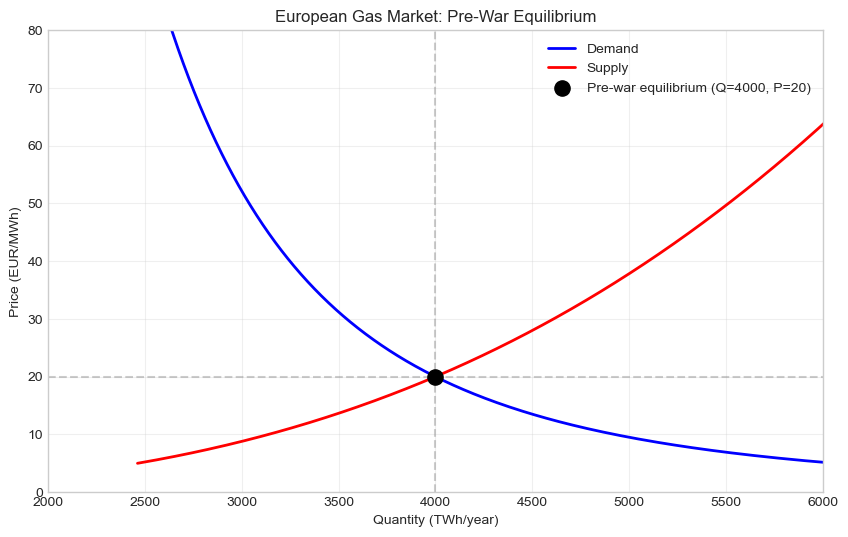

In [5]:
# Plot pre-war equilibrium
prices = np.linspace(5, 80, 500)
qd = demand(prices, A_d, eps_d)
qs = supply(prices, A_s, eps_s)

plt.figure(figsize=(10, 6))
plt.plot(qd, prices, '-b', linewidth=2, label='Demand')
plt.plot(qs, prices, '-r', linewidth=2, label='Supply')
plt.scatter(Q0, P0, s=120, color='black', zorder=5, label=f'Pre-war equilibrium (Q={Q0:.0f}, P={P0:.0f})')
plt.axhline(y=P0, linestyle='--', color='gray', alpha=0.4)
plt.axvline(x=Q0, linestyle='--', color='gray', alpha=0.4)
plt.xlabel('Quantity (TWh/year)')
plt.ylabel('Price (EUR/MWh)')
plt.title('European Gas Market: Pre-War Equilibrium')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(2000, 6000)
plt.ylim(0, 80)
plt.show()

### 3.2 Supply Shock Simulation

The Russian invasion removed a large fraction of European gas supply. Russia's share of European gas was approximately 40%. We model this as a leftward shift of the supply curve:

$$Q_s^{\text{post}}(P) = (1 - \delta) \cdot A_s \cdot P^{\epsilon_s}$$

where $\delta$ is the fraction of supply removed. At $\delta = 0.40$, we remove 40% of total supply — roughly matching Russia's pre-war share.

**Key modeling point:** The shock removes *Russian* supply. Norwegian supply is *unchanged* — Norway still has the same supply curve $Q_{NO}(P) = A_{NO} \cdot P^{\epsilon_s}$. But the market-clearing price rises, so Norway sells at a higher price and moves up along its supply curve.

In [6]:
# Supply shock parameters
delta = 0.40            # fraction of supply removed (Russia's share)
norway_share = 0.25     # Norway's share of total pre-war supply

# Norwegian supply scale parameter (unchanged by the shock)
A_NO = norway_share * A_s

# Excess demand function for our custom solver
def excess_demand(price, params):
    A_d, eps_d, A_s, eps_s, delta = params
    return demand(price, A_d, eps_d) - supply(price, (1 - delta) * A_s, eps_s)

# Solve with secant method (Session 3 technique)
P1_secant = our_secant_solver(excess_demand, 10.0, 80.0, [A_d, eps_d, A_s, eps_s, delta])
Q1_secant = demand(P1_secant, A_d, eps_d)

# Verify with scipy.optimize.bisect
def excess_demand_scipy(price):
    return demand(price, A_d, eps_d) - supply(price, (1 - delta) * A_s, eps_s)

P1_scipy = opt.bisect(excess_demand_scipy, 1, 500)
Q1_scipy = demand(P1_scipy, A_d, eps_d)

print(f"=== New Equilibrium After Supply Shock (delta={delta:.0%}) ===")
print(f"Secant method: P1 = {P1_secant:.2f} EUR/MWh, Q1 = {Q1_secant:.1f} TWh/yr")
print(f"Scipy bisect:  P1 = {P1_scipy:.2f} EUR/MWh, Q1 = {Q1_scipy:.1f} TWh/yr")
print(f"")
print(f"Price increase: {P1_scipy/P0:.1f}x  ({(P1_scipy/P0 - 1)*100:.0f}%)")
print(f"Quantity decrease: {(1 - Q1_scipy/Q0)*100:.1f}%")
print(f"Solvers agree to {abs(P1_secant - P1_scipy):.2e} EUR/MWh")

=== New Equilibrium After Supply Shock (delta=40%) ===
Secant method: P1 = 43.89 EUR/MWh, Q1 = 3159.9 TWh/yr
Scipy bisect:  P1 = 43.89 EUR/MWh, Q1 = 3159.9 TWh/yr

Price increase: 2.2x  (119%)
Quantity decrease: 21.0%
Solvers agree to 1.35e-13 EUR/MWh


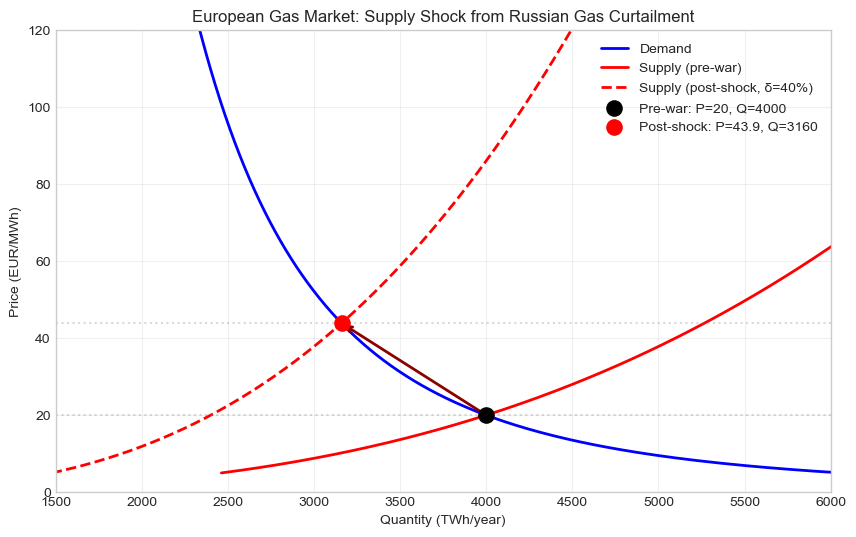

In [7]:
# Plot: pre-war vs post-shock equilibrium
prices = np.linspace(5, 120, 500)
qd = demand(prices, A_d, eps_d)
qs_pre = supply(prices, A_s, eps_s)
qs_post = supply(prices, (1 - delta) * A_s, eps_s)

plt.figure(figsize=(10, 6))
plt.plot(qd, prices, '-b', linewidth=2, label='Demand')
plt.plot(qs_pre, prices, '-r', linewidth=2, label='Supply (pre-war)')
plt.plot(qs_post, prices, '--r', linewidth=2, label=f'Supply (post-shock, δ={delta:.0%})')
plt.scatter(Q0, P0, s=120, color='black', zorder=5, label=f'Pre-war: P={P0:.0f}, Q={Q0:.0f}')
plt.scatter(Q1_scipy, P1_scipy, s=120, color='red', zorder=5,
            label=f'Post-shock: P={P1_scipy:.1f}, Q={Q1_scipy:.0f}')
plt.annotate('', xy=(Q1_scipy, P1_scipy), xytext=(Q0, P0),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2))
plt.axhline(y=P0, linestyle=':', color='gray', alpha=0.3)
plt.axhline(y=P1_scipy, linestyle=':', color='gray', alpha=0.3)
plt.xlabel('Quantity (TWh/year)')
plt.ylabel('Price (EUR/MWh)')
plt.title('European Gas Market: Supply Shock from Russian Gas Curtailment')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(1500, 6000)
plt.ylim(0, 120)
plt.show()

### 3.3 Norwegian Producer Surplus

Norwegian gas producers are price-takers in the European market. Their supply curve is $Q_{NO}(P) = A_{NO} \cdot P^{\epsilon_s}$, with $A_{NO}$ unchanged by the shock.

**Producer surplus** is the area between the equilibrium price and the supply curve:

$$PS = P \cdot Q_{NO} - \int_0^{Q_{NO}} S^{-1}(q) \, dq$$

For constant-elasticity supply $Q = A \cdot P^\epsilon$, the inverse is $P = (Q/A)^{1/\epsilon}$, and the integral has a closed form:

$$\int_0^{Q} (q/A)^{1/\epsilon} \, dq = \frac{A^{-1/\epsilon} \cdot Q^{1 + 1/\epsilon}}{1 + 1/\epsilon}$$

In [8]:
# Analytical producer surplus formula for constant-elasticity supply
def ps_analytical(eq_price, A, eps):
    Q = supply(eq_price, A, eps)
    cost_integral = A**(-1/eps) * Q**(1 + 1/eps) / (1 + 1/eps)
    revenue = eq_price * Q
    return revenue - cost_integral

# Numerical verification: "integration by force" (Session 7 technique)
def ps_numerical(eq_price, A, eps, n_grid=50000):
    Q = supply(eq_price, A, eps)
    grid = np.linspace(1e-6, Q, n_grid)
    mc = inverse_supply(grid, A, eps)
    cost = Q * np.mean(mc)
    revenue = eq_price * Q
    return revenue - cost

# Pre-war Norwegian PS
PS_pre_analytical = ps_analytical(P0, A_NO, eps_s)
PS_pre_numerical = ps_numerical(P0, A_NO, eps_s)

# Post-shock Norwegian PS (same supply curve A_NO, higher price P1)
PS_post_analytical = ps_analytical(P1_scipy, A_NO, eps_s)
PS_post_numerical = ps_numerical(P1_scipy, A_NO, eps_s)

# Convert units: TWh * EUR/MWh = 10^6 EUR => divide by 10^3 for billion EUR
scale = 1e3  # TWh * EUR/MWh / 10^3 = billion EUR

delta_PS = PS_post_analytical - PS_pre_analytical

print(f"=== Norwegian Producer Surplus ===")
print(f"Pre-war  (analytical): {PS_pre_analytical/scale:.2f} bn EUR")
print(f"Pre-war  (numerical):  {PS_pre_numerical/scale:.2f} bn EUR")
print(f"Post-shock (analytical): {PS_post_analytical/scale:.2f} bn EUR")
print(f"Post-shock (numerical):  {PS_post_numerical/scale:.2f} bn EUR")
print(f"")
print(f"Change in PS: +{delta_PS/scale:.2f} bn EUR")
print(f"Analytical vs numerical error: {abs(PS_pre_analytical - PS_pre_numerical)/scale:.6f} bn EUR")

=== Norwegian Producer Surplus ===
Pre-war  (analytical): 14.81 bn EUR
Pre-war  (numerical):  14.81 bn EUR
Post-shock (analytical): 42.80 bn EUR
Post-shock (numerical):  42.80 bn EUR

Change in PS: +27.99 bn EUR
Analytical vs numerical error: 0.000096 bn EUR


/var/folders/y8/0k7860rd36ddfkycxyl8xm6c0000gn/T/ipykernel_61276/3077652302.py:37: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y8/0k7860rd36ddfkycxyl8xm6c0000gn/T/ipykernel_61276/3077652302.py:37: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


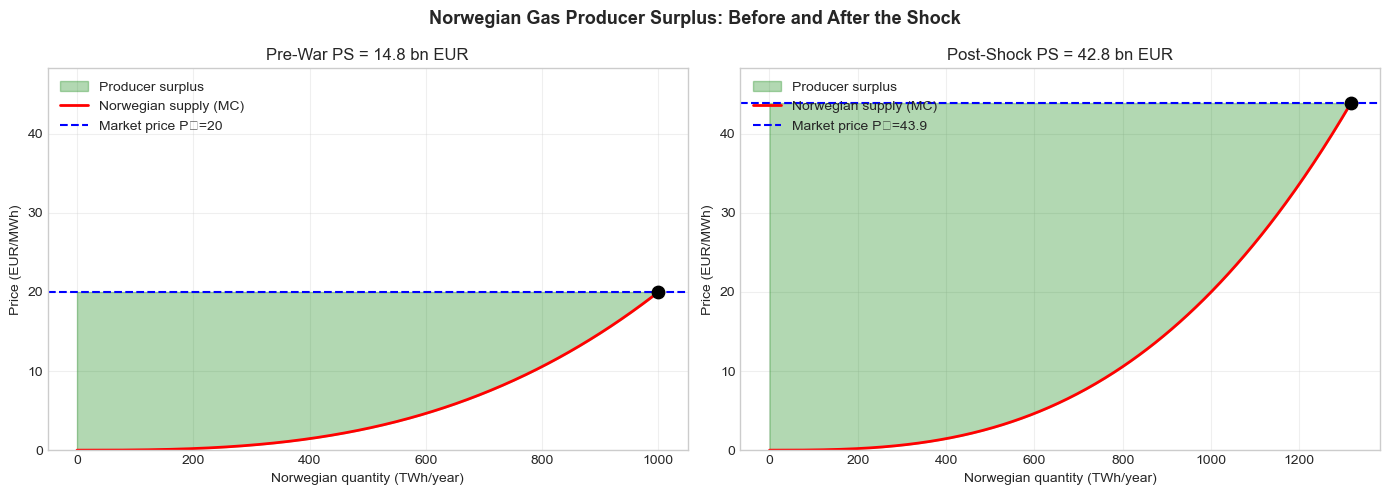

Norwegian output pre-war:   1000 TWh/yr
Norwegian output post-shock: 1317 TWh/yr (+31.7%)


In [9]:
# Visualise Norwegian producer surplus: pre-war vs post-shock
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pre-war PS
Q_NO_pre = supply(P0, A_NO, eps_s)
q_range_pre = np.linspace(1e-3, Q_NO_pre, 500)
mc_pre = inverse_supply(q_range_pre, A_NO, eps_s)

ax1.fill_between(q_range_pre, mc_pre, P0, alpha=0.3, color='green', label='Producer surplus')
ax1.plot(q_range_pre, mc_pre, '-r', linewidth=2, label='Norwegian supply (MC)')
ax1.axhline(y=P0, color='blue', linestyle='--', linewidth=1.5, label=f'Market price P₀={P0:.0f}')
ax1.scatter(Q_NO_pre, P0, s=80, color='black', zorder=5)
ax1.set_xlabel('Norwegian quantity (TWh/year)')
ax1.set_ylabel('Price (EUR/MWh)')
ax1.set_title(f'Pre-War PS = {PS_pre_analytical/scale:.1f} bn EUR')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, P1_scipy * 1.1)

# Post-shock PS
Q_NO_post = supply(P1_scipy, A_NO, eps_s)
q_range_post = np.linspace(1e-3, Q_NO_post, 500)
mc_post = inverse_supply(q_range_post, A_NO, eps_s)

ax2.fill_between(q_range_post, mc_post, P1_scipy, alpha=0.3, color='green', label='Producer surplus')
ax2.plot(q_range_post, mc_post, '-r', linewidth=2, label='Norwegian supply (MC)')
ax2.axhline(y=P1_scipy, color='blue', linestyle='--', linewidth=1.5, label=f'Market price P₁={P1_scipy:.1f}')
ax2.scatter(Q_NO_post, P1_scipy, s=80, color='black', zorder=5)
ax2.set_xlabel('Norwegian quantity (TWh/year)')
ax2.set_ylabel('Price (EUR/MWh)')
ax2.set_title(f'Post-Shock PS = {PS_post_analytical/scale:.1f} bn EUR')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, P1_scipy * 1.1)

plt.suptitle('Norwegian Gas Producer Surplus: Before and After the Shock', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Norwegian output pre-war:   {Q_NO_pre:.0f} TWh/yr")
print(f"Norwegian output post-shock: {Q_NO_post:.0f} TWh/yr (+{(Q_NO_post/Q_NO_pre - 1)*100:.1f}%)")

**Interpretation:** Norwegian gas producers gain substantially from the price surge. Although they can only modestly expand output (constrained by pipeline capacity and field production), the much higher market price means that revenue per unit increases dramatically.

*Note: The change in Norwegian output is moderate because supply elasticity is low (εₛ = 0.35). Most of the PS gain comes from the higher price on existing production, not from volume expansion.*